In [1]:
from utils import parse_rq3_table

df = parse_rq3_table("../LiteM/results/RQ3.txt")

In [2]:
df.tail(10)

,Project,Technique,File_P,File_R,File_F1,File_AUC,File_MCC,Class_P,Class_R,Class_F1,...,Method_P,Method_R,Method_F1,Method_AUC,Method_MCC,Block_P,Block_R,Block_F1,Block_AUC,Block_MCC
62,Redisson,RF,40.33,30.00,30.50,91.03,30.91,42.08,30.83,30.65,...,81.67,60.95,67.88,98.95,69.25,91.32,79.52,84.39,95.77,83.33
63,Redisson,XGB,49.32,40.83,39.72,88.05,40.62,42.50,30.83,27.69,...,61.21,60.95,57.58,98.52,58.74,82.80,81.19,81.31,91.39,79.45
64,RxJava,LiteM,57.60,47.50,50.05,88.17,49.30,59.02,43.75,48.29,...,81.82,64.71,70.43,93.77,70.86,70.38,45.42,51.56,87.20,52.98
65,RxJava,LR,26.64,40.56,25.47,77.65,24.94,44.28,33.47,27.97,...,14.58,73.57,24.29,83.50,27.31,11.36,51.25,18.54,71.20,17.47
66,RxJava,RF,53.55,51.53,50.90,91.27,49.56,52.27,42.50,44.70,...,63.77,62.24,61.26,95.02,60.65,76.58,44.31,51.54,88.99,54.22
67,RxJava,XGB,52.86,48.89,49.26,87.11,47.82,54.21,42.50,46.45,...,73.00,61.43,64.74,93.72,64.71,71.92,43.06,51.01,87.42,52.57
68,Tink,LiteM,72.34,71.54,71.45,85.41,64.71,74.06,64.95,68.57,...,77.41,57.58,65.11,88.21,63.95,16.35,30.83,20.13,64.27,19.76
69,Tink,LR,57.00,48.91,48.78,75.39,38.97,54.40,69.45,60.46,...,22.89,60.71,30.43,78.82,27.48,8.88,11.67,8.12,62.39,7.26
70,Tink,RF,72.91,66.28,68.48,86.83,61.87,71.41,65.55,67.20,...,76.91,58.21,65.15,91.33,63.97,33.06,22.50,23.36,79.57,24.47
71,Tink,XGB,67.21,68.46,67.58,84.60,59.53,74.36,64.18,68.16,...,70.82,60.04,63.24,87.62,61.63,17.37,32.50,21.83,64.39,21.48


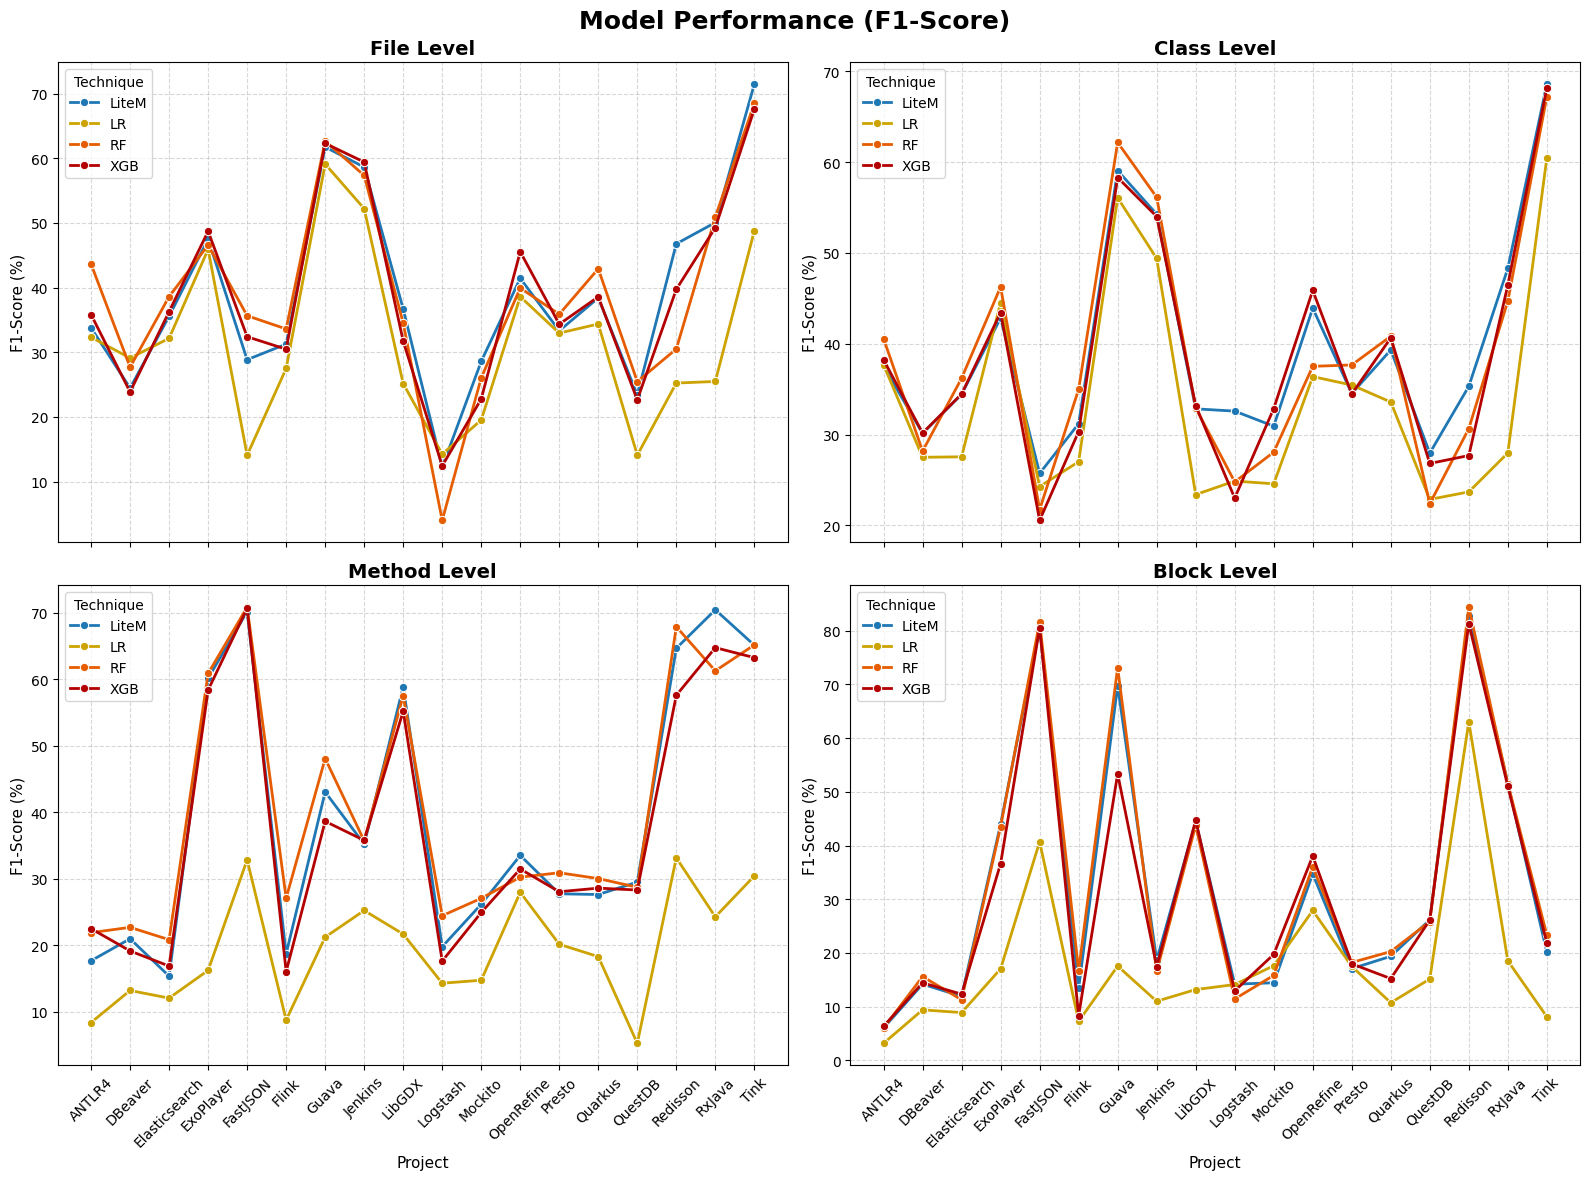

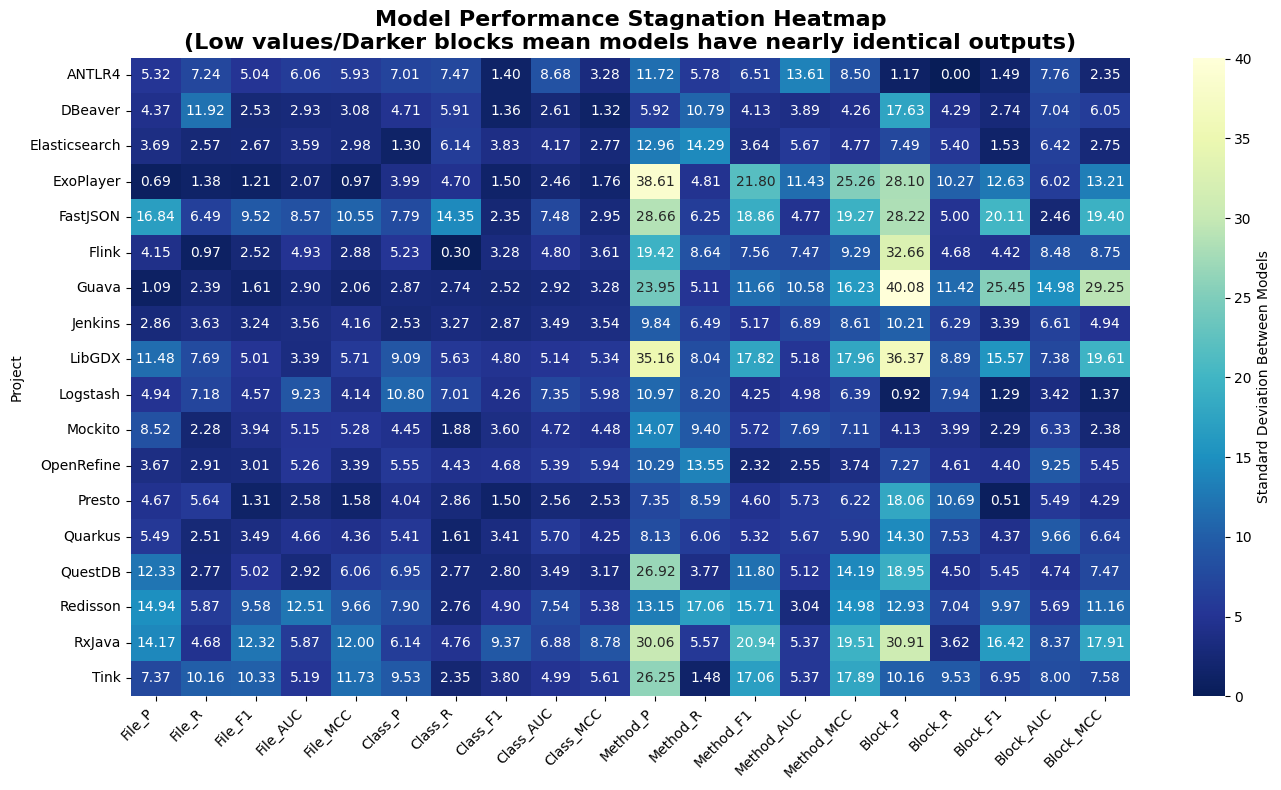

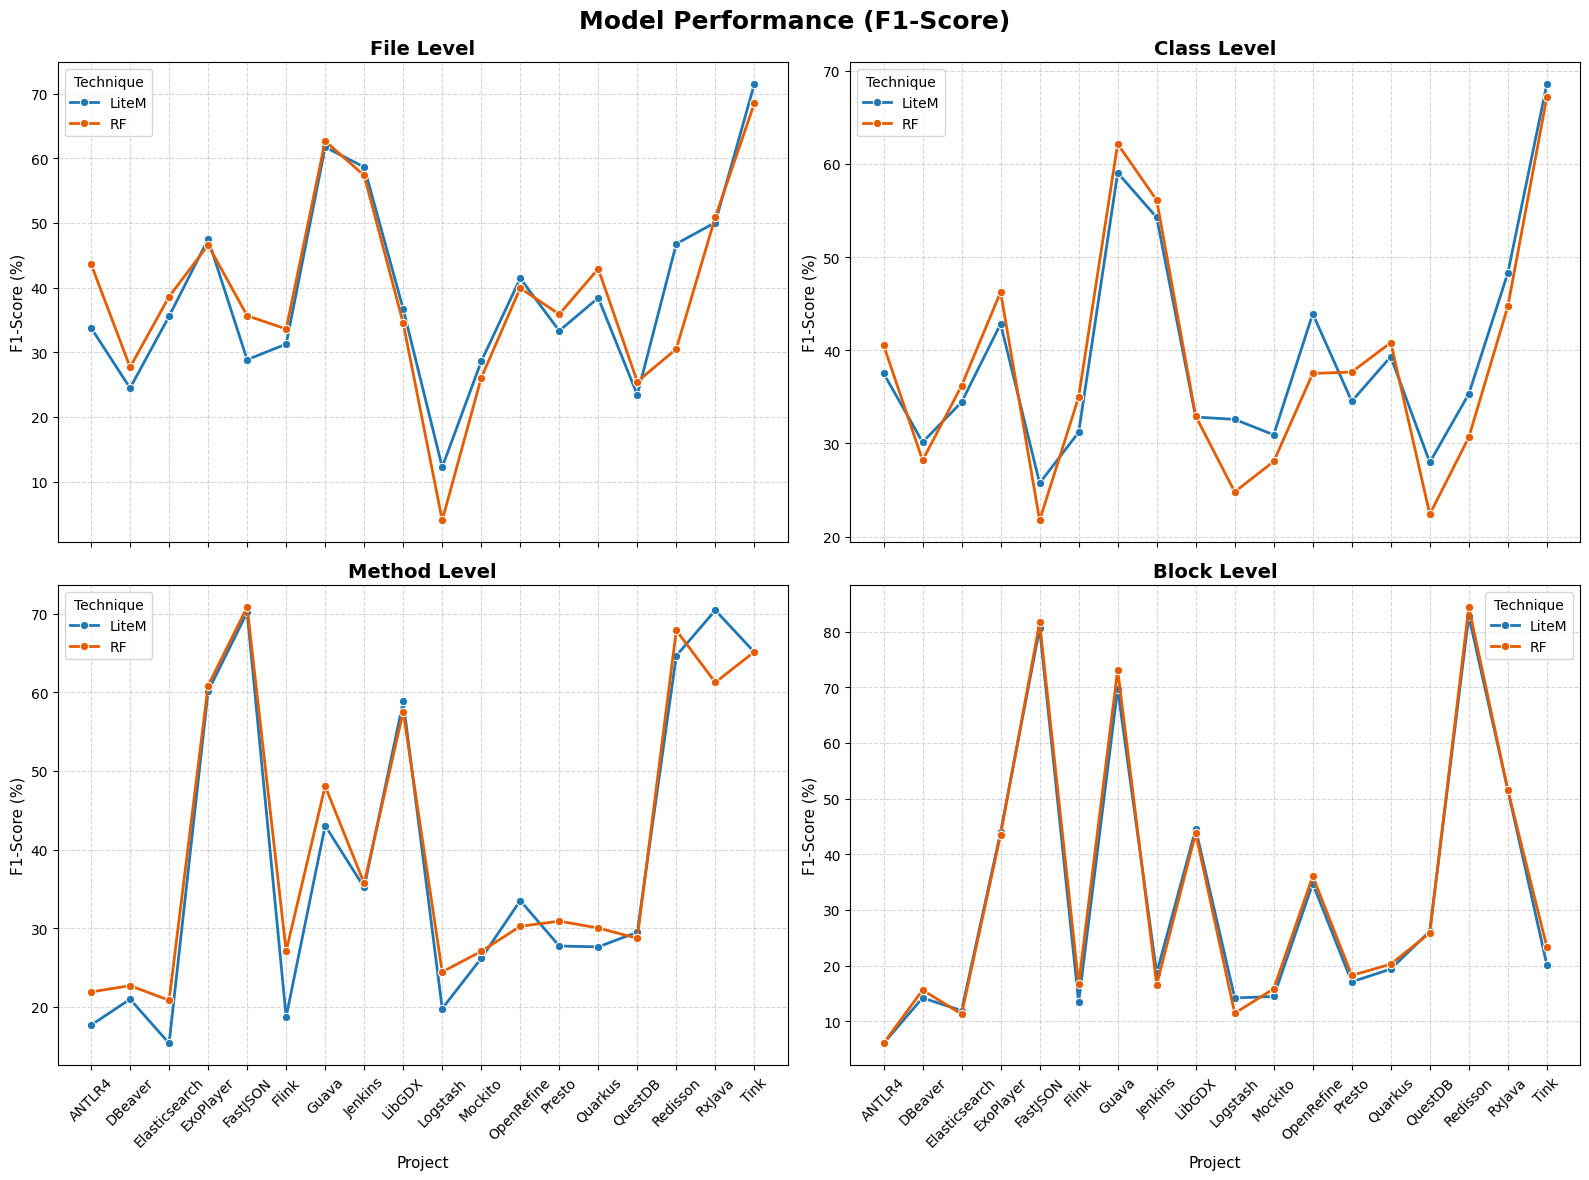

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

technique_colors = {
    # Cold color (Your main model)
    'LiteM': '#1f77b4',  # Deep Slate Blue (Stands out as the anchor)
    
    # Warm colors (The competitors)
    'RF': '#e65c00',     # Rich Orange (Warm and highly visible)
    'LR': '#cca300',     # Dark Mustard/Gold (Much easier to see than pure yellow)
    'XGB': '#b30000'     # Crimson Red (Deep and professional, not blinding)
}

# --- ASSUMPTION: Your DataFrame 'df' is already loaded here ---
# Filter out the 'Average' rows if they were parsed into your main dataframe rows
df_projects = df[df['Project'] != 'Average'].copy()

# ==============================================================================
# VISUALIZATION 1: F1-Score Performance Trajectories
# ==============================================================================
GRANULARITIES = ['File', 'Class', 'Method', 'Block']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, gran in enumerate(GRANULARITIES):
    col_name = f'{gran}_F1'
    
    # Lineplot to see if the techniques track right on top of each other
    sns.lineplot(
        data=df_projects, 
        x='Project', 
        y=col_name, 
        palette=technique_colors,
        hue='Technique', 
        marker='o', 
        linewidth=2,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{gran} Level', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('F1-Score (%)', fontsize=11)
    axes[i].set_xlabel('Project', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Model Performance (F1-Score)", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# ==============================================================================
# VISUALIZATION 2: Multi-Metric Variance Heatmap
# ==============================================================================
# This calculates the Standard Deviation between techniques within each project.
# A standard deviation near 0 means the models are outputting nearly identical numbers.

metrics = ['P', 'R', 'F1', 'AUC', 'MCC']
heatmap_data = []

# Group by project, and calculate variance across the models
for proj, group in df_projects.groupby('Project'):
    row_variance = {'Project': proj}
    for gran in GRANULARITIES:
        for metric in metrics:
            col = f'{gran}_{metric}'
            # Standard deviation among the 4 techniques for this specific project & metric
            row_variance[f'{gran}_{metric}'] = group[col].std()
    heatmap_data.append(row_variance)

df_variance = pd.DataFrame(heatmap_data).set_index('Project')

# Let's pick a specific granularity (e.g., File level metrics) or plot everything together
plt.figure(figsize=(14, 8))
sns.heatmap(
    df_variance, 
    cmap='YlGnBu_r',  # Dark blue/green means low variance (models are identical)
    annot=True, 
    fmt=".2f", 
    cbar_kws={'label': 'Standard Deviation Between Models'}
)

plt.title("Model Performance Stagnation Heatmap\n(Low values/Darker blocks mean models have nearly identical outputs)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# ==============================================================================
# VISUALIZATION 3: F1-Score Performance LiteM vs Random Forest
# ==============================================================================
GRANULARITIES = ['File', 'Class', 'Method', 'Block']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

df_only_LiteM_and_RF = df_projects[(df_projects["Technique"] == "LiteM") | (df_projects["Technique"] == "RF")]

for i, gran in enumerate(GRANULARITIES):
    col_name = f'{gran}_F1'
    
    # Lineplot to see if the techniques track right on top of each other
    sns.lineplot(
        data=df_only_LiteM_and_RF, 
        x='Project', 
        y=col_name, 
        palette=technique_colors,
        hue='Technique', 
        marker='o', 
        linewidth=2,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{gran} Level', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('F1-Score (%)', fontsize=11)
    axes[i].set_xlabel('Project', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Model Performance (F1-Score)", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()



In [6]:
df_only_LiteM_and_RF.columns

Index(['Project', 'Technique', 'File_P', 'File_R', 'File_F1', 'File_AUC',
       'File_MCC', 'Class_P', 'Class_R', 'Class_F1', 'Class_AUC', 'Class_MCC',
       'Method_P', 'Method_R', 'Method_F1', 'Method_AUC', 'Method_MCC',
       'Block_P', 'Block_R', 'Block_F1', 'Block_AUC', 'Block_MCC'],
      dtype='str')

In [8]:
# --- Configurações Iniciais ---
METRIC = "F1"
# Estas são as granularidades mapeadas diretamente dos prefixos das suas colunas
GRANULARITIES = ["File", "Class", "Method", "Block"]  

LiteM_wins = 0
RF_wins = 0

PROJECTS = df_only_LiteM_and_RF.Project.unique()

# --- Loop de Comparação ---
for project in PROJECTS:
    for granularity in GRANULARITIES:
        
        # 1. Filtra o dataset apenas pelo projeto atual
        df_filtered = df_only_LiteM_and_RF[df_only_LiteM_and_RF["Project"] == project]
        
        # Monta o nome exato da coluna baseado no seu padrão (ex: "File_F1", "Class_F1")
        metric_col = f"{granularity}_{METRIC}"
        
        # Garante que a coluna existe e que o dataframe não está vazio
        if metric_col not in df_filtered.columns or df_filtered.empty:
            continue
            
        # 2. Extrai os scores para cada técnica dentro deste projeto
        litem_scores = df_filtered[df_filtered["Technique"] == "LiteM"][metric_col].dropna().values
        rf_scores = df_filtered[df_filtered["Technique"] == "RF"][metric_col].dropna().values
        
        # 3. Compara corrida por corrida (linha a linha) de forma emparelhada
        for litem_val, rf_val in zip(litem_scores, rf_scores):
            if litem_val > rf_val:
                LiteM_wins += 1
            elif rf_val > litem_val:
                RF_wins += 1
            else:
                print("Uia, empate!")

# --- Resultados Finais ---
print("--- Placar Head-to-Head por Rodada/Configuração ---")
print(f"LiteM: {LiteM_wins} vitórias")
print(f"RF: {RF_wins} vitórias")

Uia, empate!
--- Placar Head-to-Head por Rodada/Configuração ---
LiteM: 28 vitórias
RF: 43 vitórias
